Algunos de los principales aspectos prácticos del uso de `numpy` que aprenderemos son:

* Creación y manejo de `ndarray`: arrays multidimensionales eficientes que permiten entre otras cosas realizar operaciones aritméticas rápidas a nivel de vectores, matrices, etc.

* Funciones matemáticas para operar sobre elementos de arrays sin necesidad de bucles.

* Herramienta de lectura/escritura de datos contenidos en arrays en disco.

* Operaciones de álgebra lineal, estadística, cálculo, generación de números aleatorios, etc.

**Configuración inicial**

Este primer fragmento de código muestra cómo definir una semilla para la generación de números aleatorios. Es un mecanismo para asegurar reproducibilidad en código donde habrá componentes de aleatoriedad.

También realiza una configuración de tamaño de figuras que más tarde visualizaremos con `matplotlib`.

Por último, en lo que a `numpy` respecta, se definen las opciones para precisión decimal con la que se mostrarán valores, y con la opción `suppress`activada impediremos el uso de notación científica al mostrar valores grandes o muy pequeños.

In [1]:
import numpy as np
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

Una comparación de la eficiencia entre arrays numpy y listas convencionales, con una estructura de 1M de enteros.

In [2]:
import numpy as np

my_arr = np.arange(1_000_000)
my_list = list(range(1_000_000))

Veamos el tiempo requerido para multiplicar el colección al completo por dos en cada una de las dos estructuras.

In [3]:
%timeit my_arr2 = my_arr * 2
%timeit my_list2 = [x * 2 for x in my_list]

The slowest run took 4.92 times longer than the fastest. This could mean that an intermediate result is being cached.
2.14 ms ± 1.2 ms per loop (mean ± std. dev. of 7 runs, 1000 loops each)
76.2 ms ± 16.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### `ndarray`: Arrays multidimensionales

In [4]:
import numpy as np

# Definir manualmente un pequeño array bidimensional (matriz)
data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

In [5]:
# Operaciones aritméticas sobre ndarrays
data * 10
data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

In [6]:
data.shape # Dimensiones del ndarray
data.dtype # Tipo de dato en los elementos del ndarray (deben ser homogéneos)

dtype('float64')

In [7]:
data1 = [6, 7.5, 8, 0, 1]
# la función np.array() crea un ndarray a partir de una lista simple o anidada
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

In [8]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [9]:
arr2.ndim # Número de dimensiones del array
# arr2.shape

2

In [10]:
arr1.dtype
# arr2.dtype

dtype('float64')

Además de `np.array()`, hay otras funciones para crear ciertos tipos de arrays.

In [11]:
np.zeros(10) # Array of 0s
np.zeros((3, 6)) # Para dimensiones 2 o superiores, el argumento pasa a ser una tupla
np.ones(4)
np.empty((2, 3, 2)) # Esta función recurre a memoria no usada para inicializar un array
# No es muy confiable porque algunos elementos pueden contener valores residuales

array([[[0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.]]])

In [12]:
# Una versión "array" de la función nativa de Python 'range'
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [13]:
cadena = ('hola','numpy')
arrc = np.asarray(cadena)
arrc

array(['hola', 'numpy'], dtype='<U5')

In [14]:
# Argumento adicional para especificar el tipo de dato en el array a crear
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)
arr1.dtype
arr2.dtype

dtype('int32')

In [15]:
arr = np.array([1, 2, 3, 4, 5])
arr.dtype

dtype('int64')

Conversión explícita (Casting) del array recién creado de tipo entero, a otro tipo: real.

In [16]:
float_arr = arr.astype(np.float64)
float_arr
float_arr.dtype

dtype('float64')

In [17]:
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr
arr.astype(np.int32)
# Convertir de float a entero en arrays trunca la parte decimal

array([ 3, -1, -2,  0, 12, 10], dtype=int32)

In [18]:
# Conversión de cadenas a reales
numeric_strings = np.array(["1.25", "-9.6", "42", "1e3"])
numeric_strings.astype(float)

array([   1.25,   -9.6 ,   42.  , 1000.  ])

In [19]:
int_array = np.arange(10)
decimales = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)
# Darle a un array el tipo de otro array
int_array.astype(decimales.dtype)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

### Operaciones aritméticas con arrays en NumPy

In [20]:
# Suma y producto por lotes
# (esta forma de operar sin necesidad de bucles se llama vectorización)
# Operar a nivel de elementos, requiere, por supuesto que los 2 operandos sean
# arrays de idénticas dimensiones.

arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr
arr * arr
# arr - arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [21]:
# Operaciones entre array y escalar "extienden" el escalar a todos los elems.
1 / arr
# arr ** 2

array([[1.    , 0.5   , 0.3333],
       [0.25  , 0.2   , 0.1667]])

In [22]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2
arr2 > arr
# La comparación entre 2 arrays de igual tamaño da un array de booleanos

array([[False,  True, False],
       [ True, False,  True]])

In [23]:
arr = np.arange(10)
arr
arr[5]
arr[5:8] # Acceso y slicing es similar a listas nativas de Python
arr[5:8] = 12 # El valor a asignar se aplica a toda la selección o porción
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

In [24]:
arr_slice = arr[5:8] # Crear un array a partir de una porción de otro
arr_slice
# CUIDADO: las porciones (slicing) son "vistas lógicas" del array original, no crean copias

array([12, 12, 12])

In [25]:
arr_slice[1] = 12345
arr
# Por tanto, un cambio al nuevo array que es una porción del anterior,
# afecta también al array completo

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

In [26]:
arr_slice[:] = 64 # arr_slice tiene "memorizada" la porción del array original de la que procede
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [27]:
arr_slice_copiado = arr[5:8].copy() # Asi se puede hacer una copia real e independiente
arr_slice_copiado[0] = -1
arr
arr_slice_copiado

array([-1, 64, 64])

In [28]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d[2]
# En arrays multidimensional, una indexación simple no da un escalar sino un subarray 1d

array([7, 8, 9])

In [29]:
# Dos modos de acceder a un elemento de un array multidimensional
arr2d[0][2]
arr2d[0, 2]
int(arr2d[0,2])

3

In [30]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [31]:
arr3d[0] # Indexación simple en un array 3d: devuelve array 2d

array([[1, 2, 3],
       [4, 5, 6]])

In [32]:
valores_antiguos = arr3d[0].copy()
arr3d[0] = 42 # Asignación que afecta al subarray 2d al completo
arr3d
arr3d[0] = valores_antiguos # Con la copia hecha antes recuperamos valores antiguos
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [33]:
arr3d[1, 0] # Doble indexación en array 3d devuelve array 1d

array([7, 8, 9])

In [34]:
x = arr3d[1]
x
x[0] # Indexación en dos pasos: x contiene una vista de arr3d, no es una copia

array([7, 8, 9])

In [35]:
# Acceso mediante slicing/porciones en arrays multidimensionales
arr2d
arr2d[:2] # La porción seleccionada abarca filas de la matriz (primer eje o dimensión)

array([[1, 2, 3],
       [4, 5, 6]])

In [36]:
arr2d[:2, 1:] # Primera porción a nivel de filas, segunda a nivel de columnas

array([[2, 3],
       [5, 6]])

In [37]:
lower_dim_slice = arr2d[1, :2] # Elegir segunda fila y dos primeras columnas

In [38]:
lower_dim_slice.shape # el resultado para a ser 1-dimensional

(2,)

In [39]:
arr2d[:2, 2] # Elegir dos primeras filas, y solo 3a columna

array([3, 6])

In [40]:
arr2d[:, :1] # Elegir todas las filas, y solo primera columna

array([[1],
       [4],
       [7]])

In [41]:
arr2d[:2, 1:] = 0 # Asignación que afecta a una selección completa
arr2d

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

**Indexación booleana:**

In [42]:
# array con nombres duplicados
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2],
                 [-12, -4], [3, 4]])
# En el segundo array, la 1a dimensión es tamaño 7, igual que en el anterior array 1d
names
data

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [43]:
names == "Bob" # La condición se verifica en cada elemento del array

array([ True, False, False,  True, False, False, False])

In [44]:
data[names == "Bob"]
# En 'data', accedemos a los índices asociados a posiciones de 'names' donde se cumple la condición
# Es como una "indexación personalizada", en este caso tomamos las filas 1a y 4a

array([[4, 7],
       [0, 0]])

In [45]:
# Esta forma de indexar se puede combinar con la simple y slices
data[names == "Bob", 1:]
data[names == "Bob", 1]

array([7, 0])

In [46]:
names != "Bob"
~(names == "Bob")
data[~(names == "Bob")] # Datos asociados a personas distintas de Bob

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [47]:
cond = names == "Bob"
cond
data[~cond]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [48]:
mascara = (names == "Bob") | (names == "Will") # Selección de dos nombres diferentes
# Este tipo de asignación a una nueva variable a partir de indexación booleana
# curiosamente sí que crea una copia física del array de origen.
mascara
data[mascara]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

In [49]:
data[data < 0] = 0 # Asignación aplicable a elementos que cumplen la condición
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

In [50]:
data[names != "Joe"] = 7 # también se puede hacer usando otro array, en este caso 1d
data

array([[7, 7],
       [0, 2],
       [7, 7],
       [7, 7],
       [7, 7],
       [0, 0],
       [3, 4]])

Buena parte de las operaciones a nivel 2-dimensional que hemos ilustrado serán útiles cuando empecemos a utilizar Pandas para el manejo de datasets.

In [51]:
arr = np.zeros((8, 4))
for i in range(8):
    arr[i] = i
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [52]:
# Indexado usando arrays de enteros:
# permite por ejemplo seleccionar varias filas cualquiesquiera
arr[[4, 3, 0, 6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

In [53]:
arr[[-3, -5, -7]] # selección de filas empezando desde el final

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

In [54]:
arr = np.arange(32).reshape((8, 4)) # Reestructurar el array 1d a 2d
arr
arr[[1, 5, 7, 2], [0, 3, 1, 2]]
# se seleccionan las posiciones (1,0), la (5,3), etc.
# Un comportamiento algo inesperado si lo que buscamos era una selección filas-columnas

array([ 4, 23, 29, 10])

In [55]:
# Así se puede obtener una selección de filas x columnas
# Nótese que seleccionamos 4 columnas pero ya de por si habia 4
# pero las elegimos en el orden deseado: hemos hecho una permutación de columnas.
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

In [56]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]
arr[[1, 5, 7, 2], [0, 3, 1, 2]] = 0
arr

array([[ 0,  1,  2,  3],
       [ 0,  5,  6,  7],
       [ 8,  9,  0, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22,  0],
       [24, 25, 26, 27],
       [28,  0, 30, 31]])

**Transposición de arrays e intercambio de ejes**

In [57]:
arr = np.arange(15).reshape((3, 5)) # 3 filas, 5 columnas
arr
arr.T # 5 filas, tres columnas

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [58]:
arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
arr
np.dot(arr.T, arr) # Producto interior entre matrices 3x5 y 5x3

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

In [59]:
arr.T @ arr # otro modo de efectuar producto entre matrices

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

In [60]:
arr
arr.swapaxes(0, 1) # Este método toma dos ejes (dimensiones) de los arrays y los intercambia
# Es un caso más general del .T para transponer matrices.

array([[ 0,  1,  6, -1,  1],
       [ 1,  2,  3,  0,  0],
       [ 0, -2,  2, -1,  1]])

**Generación de números pseudoaleatorios**:
se hace principalmente mediante el módulo `random` de `numpy`.

In [61]:
samples = np.random.standard_normal(size=(4, 4))
# Matriz 4x4 de números aleatoramente generados
# a partir de una distribución normal estándar
samples

array([[-0.2047,  0.4789, -0.5194, -0.5557],
       [ 1.9658,  1.3934,  0.0929,  0.2817],
       [ 0.769 ,  1.2464,  1.0072, -1.2962],
       [ 0.275 ,  0.2289,  1.3529,  0.8864]])

In [62]:
from random import normalvariate
N = 1_000_000
# Comparación de la eficiencia entre 'random' nativo de Python y el de 'numpy'
# para generar una gran cantidad de números aleatorios
%timeit samples = [normalvariate(0, 1) for _ in range(N)]
%timeit np.random.standard_normal(N)

571 ms ± 10.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
30 ms ± 923 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [63]:
# Personalización del generador/semilla de números aleatorios por defecto
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((2, 3))
data

array([[-1.4238,  1.2637, -0.8707],
       [-0.2592, -0.0753, -0.7409]])

In [64]:
type(rng)

numpy.random._generator.Generator

In [65]:
data = rng.integers(0, 10, size=(4, 2))
data

array([[5, 5],
       [2, 1],
       [2, 6],
       [6, 9]])

Otras funciones para generar números pseudoaleatorios incluyen: `uniform`, `binomial`, `gamma`, etc.

Funciones matemáticas sobre elementos de ndarrays:

In [66]:
arr = np.arange(10)
arr
np.sqrt(arr) # x^2
np.exp(arr) # e elevado a x

array([   1.    ,    2.7183,    7.3891,   20.0855,   54.5982,  148.4132,
        403.4288, 1096.6332, 2980.958 , 8103.0839])

In [67]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)
x
y
np.add(x,y)
np.maximum(x, y)

array([ 2.3474,  1.399 ,  1.3223,  0.9022,  0.9029, -0.0607,  0.7888,
        0.4495])

In [68]:
arr = rng.standard_normal(7) * 5
arr
parte_decimal, parte_entera = np.modf(arr)
# modf() devuelve dos arrays, con las partes entera
# y decimal de los elementos del array original
parte_decimal
parte_entera

array([-6., -0.,  8., 13.,  3.,  4., -4.])

**Operaciones vectorizadas**: suelen ser más rápidas que sus equivalentes en Python estándar.

In [69]:
points = np.arange(-5, 5, 0.01) # 100 puntos igualmente separados entre -5 y 5
xs, ys = np.meshgrid(points, points)
# Produce 2 matrices a partir de 2 arrays 1d, replicando valores a nivel de filas o columnas
xs
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

In [70]:
# Con este método antes iniciado, es posible aplicar
# una función matemática como sqrt(x^2 + y^2)
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.0711, 7.064 , 7.0569, ..., 7.0499, 7.0569, 7.064 ],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       ...,
       [7.0499, 7.0428, 7.0357, ..., 7.0286, 7.0357, 7.0428],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569]])

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1568/2543554291.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Gráfico de la función $\sqrt{x^2 + y^2}$ para una malla rectangular de valores")


Text(0.5, 1.0, 'Gráfico de la función $\\sqrt{x^2 + y^2}$ para una malla rectangular de valores')

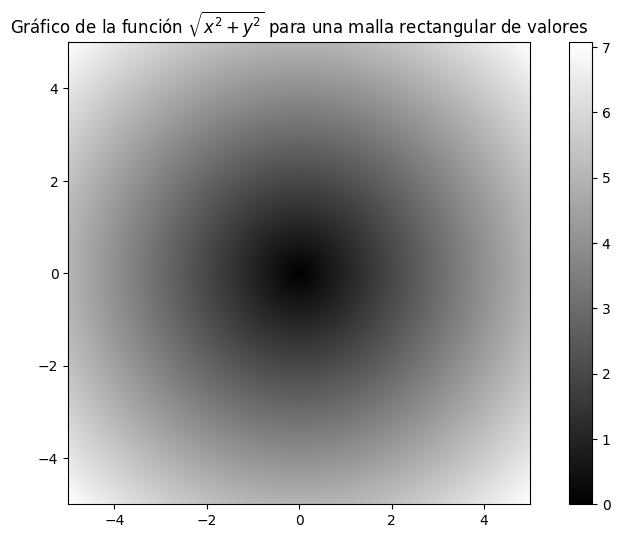

In [71]:
import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Gráfico de la función $\sqrt{x^2 + y^2}$ para una malla rectangular de valores")

In [72]:
plt.draw()

<Figure size 1000x600 with 0 Axes>

In [73]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

In [74]:
# Tomar valores de un array (x) u otro (y) según una condición dada por un tercer array booleano
result = [(x if c else y)
          for x, y, c in zip(xarr, yarr, cond)]
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

In [75]:
# Hay una forma mucho mejor de hacer esto con numpy.where:
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

In [76]:
arr = rng.standard_normal((4, 4))
arr
arr > 0
np.where(arr > 0, 2, -2) # argumentos: condición, elem. si se cumple, elem. si no se cumple

array([[-2, -2,  2,  2],
       [-2, -2,  2,  2],
       [-2,  2, -2, -2],
       [-2,  2,  2,  2]])

In [77]:
np.where(arr > 0, 2, arr) # Modificar con '2' solo los valores positivos

array([[-1.2094, -1.4123,  2.    ,  2.    ],
       [-0.6588, -1.2287,  2.    ,  2.    ],
       [-0.1308,  2.    , -0.093 , -0.0662],
       [-1.1082,  2.    ,  2.    ,  2.    ]])

**Métodos estadísticos**

In [78]:
arr = rng.standard_normal((5, 4))
arr
arr.mean()
np.mean(arr)
arr.sum()

np.float64(-2.8529672901191505)

In [79]:
arr.mean(axis=1) # se calcula el estadístico/media en cada fila, recorriendo columnas
arr.sum(axis=0) # suma de cada columna, recorriendo filas

array([-1.3783,  1.5922, -2.836 , -0.231 ])

In [80]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28])

In [81]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [82]:
arr.cumsum(axis=0)
arr.cumsum(axis=1)

array([[ 0,  1,  3],
       [ 3,  7, 12],
       [ 6, 13, 21]])

**Métodos para arrays booleanos**

In [83]:
arr = rng.standard_normal(100)
(arr > 0).sum() # Recuento del número de valores que son positivos
(arr <= 0).sum() # Recuento de valores no positivos

np.int64(52)

In [84]:
bools = np.array([False, False, True, False])
bools.any()
bools.all()

np.False_

In [85]:
arr = rng.standard_normal(6)
arr
arr.sort()
arr

array([-0.0824, -0.0548,  0.4059,  0.936 ,  1.2385,  1.2728])

In [86]:
arr = rng.standard_normal((5, 3))
arr

array([[-0.0503,  0.2893,  0.1793],
       [ 1.3975,  0.292 ,  0.6384],
       [-0.0279,  1.3711, -2.0528],
       [ 0.3805,  0.7554, -1.1591],
       [ 2.1503, -0.1503, -0.1612]])

In [87]:
arr.sort(axis=0)
arr
arr.sort(axis=1)
arr

array([[-2.0528, -0.1503, -0.0503],
       [-1.1591, -0.0279,  0.2893],
       [-0.1612,  0.292 ,  0.3805],
       [ 0.1793,  0.7554,  1.3975],
       [ 0.6384,  1.3711,  2.1503]])

In [88]:
arr2 = np.array([5, -10, 7, 1, 0, -3])
sorted_arr2 = np.sort(arr2)
sorted_arr2

array([-10,  -3,   0,   1,   5,   7])

In [89]:
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])
np.unique(names)
ints = np.array([3, 3, 3, 2, 2, 1, 1, 4, 4])
np.unique(ints)

array([1, 2, 3, 4])

In [90]:
sorted(set(names))

[np.str_('Bob'), np.str_('Joe'), np.str_('Will')]

In [91]:
values = np.array([6, 0, 0, 3, 2, 5, 6])
np.in1d(values, [2, 3, 6])

/tmp/ipykernel_1568/1293837718.py:2: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  np.in1d(values, [2, 3, 6])


array([ True, False, False,  True,  True, False,  True])

In [92]:
arr = np.arange(10)
np.save("some_array", arr)

In [93]:
np.load("some_array.npy")

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [94]:
np.savez("array_archive.npz", a=arr, b=arr)

In [95]:
arch = np.load("array_archive.npz")
arch["b"]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [96]:
np.savez_compressed("arrays_compressed.npz", a=arr, b=arr)

In [97]:
!rm some_array.npy
!rm array_archive.npz
!rm arrays_compressed.npz

In [98]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1, 7], [8, 9]])
x
y
x.dot(y)

array([[ 28.,  64.],
       [ 67., 181.]])

In [99]:
np.dot(x, y)

array([[ 28.,  64.],
       [ 67., 181.]])

In [100]:
x @ np.ones(3)

array([ 6., 15.])

In [101]:
from numpy.linalg import inv, qr
X = rng.standard_normal((5, 5))
mat = X.T @ X
inv(mat)
mat @ inv(mat)

array([[ 1., -0., -0.,  0.,  0.],
       [ 0.,  1., -0.,  0., -0.],
       [ 0.,  0.,  1.,  0., -0.],
       [ 0.,  0., -0.,  1., -0.],
       [ 0.,  0.,  0., -0.,  1.]])

In [102]:
import random
position = 0
walk = [position]
nsteps = 1000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)


In [103]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

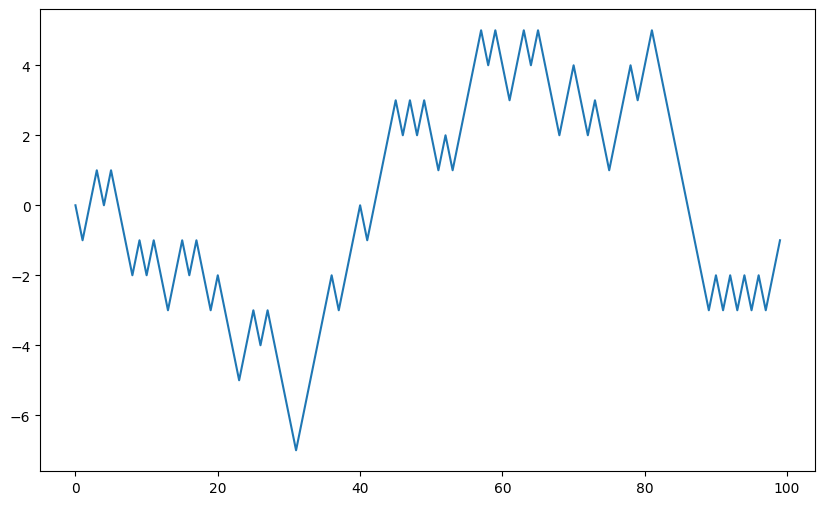

In [104]:
plt.plot(walk[:100])

In [105]:
nsteps = 1000
rng = np.random.default_rng(seed=12345)  # fresh random generator
draws = rng.integers(0, 2, size=nsteps)
steps = np.where(draws == 0, 1, -1)
walk = steps.cumsum()

In [106]:
walk.min()
walk.max()

np.int64(50)

In [107]:
(np.abs(walk) >= 10).argmax()

np.int64(155)

In [108]:
nwalks = 5000
nsteps = 1000
draws = rng.integers(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(axis=1)
walks

array([[  1,   2,   3, ...,  22,  23,  22],
       [  1,   0,  -1, ..., -50, -49, -48],
       [  1,   2,   3, ...,  50,  49,  48],
       ...,
       [ -1,  -2,  -1, ..., -10,  -9, -10],
       [ -1,  -2,  -3, ...,   8,   9,   8],
       [ -1,   0,   1, ...,  -4,  -3,  -2]])

In [109]:
walks.max()
walks.min()

np.int64(-120)

In [110]:
hits30 = (np.abs(walks) >= 30).any(axis=1)
hits30
hits30.sum() # Number that hit 30 or -30

np.int64(3395)

In [111]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(axis=1)
crossing_times

array([201, 491, 283, ..., 219, 259, 541])

In [112]:
crossing_times.mean()

np.float64(500.5699558173785)

In [113]:
draws = 0.25 * rng.standard_normal((nwalks, nsteps))